# Supervised Learning - Stage 1

Stage 1 covers:
- Feature Selection
- Leakage Removal
- Train/Test split
- Class Imbalance Analysis

In [ ]:
# Install the relevant packages in the environment this notebook runs in
import sys  # noqa: F401

!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scipy pyyaml pypickle


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')

ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'


with open(ROOT_DIR / 'config.yml') as f:
    cfg = yaml.safe_load(f)

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)
    
NB_CONFIG = {
    'figsize_wide':      nb_cfg['plotting']['figsize_wide'],
    'figsize_square':    nb_cfg['plotting']['figsize_square'],
    'palette':           nb_cfg['plotting']['palette'],
    'severity_labels':   {int(k): v for k, v in nb_cfg['labels']['severity'].items()},
}

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Pipeline config loaded from: config.yml')
print('Notebook config loaded from: notebook-config.yml')

Project root: C:\Users\abdul\Documents\SHU\AI 1\Sheffield-Road-Collision-Detection-Coursework
Pipeline config loaded from: config.yml
Notebook config loaded from: notebook-config.yml


---
# 2. Load Clean Data

In [59]:
df = pd.read_csv(ROOT_DIR / cfg['preprocessing']['output_path'])

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (7324, 32)
Columns: ['collision_index', 'collision_year', 'location_easting_osgr', 'location_northing_osgr', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'day_of_week', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'collision_injury_based', 'hour_of_day', 'month', 'is_weekend', 'time_period', 'multi_vehicle']


,collision_index,collision_year,location_easting_osgr,location_northing_osgr,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,local_authority_highway_current,first_road_class,...,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,collision_injury_based,hour_of_day,month,is_weekend,time_period,multi_vehicle
0,2.02E+12,2020,1.000000,1.000000,3,0.5,1,5,E08000019,6,...,0,1,1,2.0,1,8,1,0,0,0
1,201514K199215,2015,1.000000,1.000000,2,0.5,1,1,E08000019,3,...,0,1,1,2.0,0,21,8,1,3,0
2,201514K276515,2015,0.782659,0.441915,3,0.5,1,1,E08000019,3,...,0,1,1,2.0,0,12,11,1,1,0


---
# 3. Feature Selection and Leakage Removal

Before splitting, we must identify and remove columns that would constitute data leakage - features that either directly encode the target or would not be available at prediction time.

| Column | Reason for removal |
|--------|-------------------|
| `collision_index` | Unique row identifier - no predictive signal |
| `collision_injury_based` | Directly derived from severity outcome - leakage |
| `local_authority_highway_current` | High-cardinality string not numerically encoded |

In [ ]:
y = df[cfg['supervised']['target_col']].copy()

# Drop target + leakage/unusable columns from feature matrix
cols_to_drop = [cfg['supervised']['target_col']] + [c for c in cfg['supervised']['leakage_drop_cols'] if c in df.columns]  # noqa: E501
X = df.drop(columns=cols_to_drop)

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print('\nFeatures used:')
for col in X.columns:
    print(f'\t{col}')

Feature matrix shape: (7324, 28)
Target shape: (7324,)

Features used:
	collision_year
	location_easting_osgr
	location_northing_osgr
	number_of_vehicles
	number_of_casualties
	day_of_week
	first_road_class
	first_road_number
	road_type
	speed_limit
	junction_detail
	junction_control
	second_road_class
	second_road_number
	pedestrian_crossing
	light_conditions
	weather_conditions
	road_surface_conditions
	special_conditions_at_site
	carriageway_hazards
	urban_or_rural_area
	did_police_officer_attend_scene_of_accident
	trunk_road_flag
	hour_of_day
	month
	is_weekend
	time_period
	multi_vehicle


---
# 4. Class Imbalance Strategy

Before splitting, we must examine the distribution of collision_severity to understand the imbalance problem. This directly informs the strategy used in Stage 2 (SMOTE).

In [61]:
class_counts = y.value_counts().sort_index()
class_pcts = (class_counts / len(y) * 100).round(2)

imbalance_df = pd.DataFrame({
    'Class': [NB_CONFIG['severity_labels'][i] for i in class_counts.index],
    'Count': class_counts.values,
    'Percentage': class_pcts.values
})

print('Class distribution:')
print(imbalance_df.to_string(index=False))

majority_ratio = class_counts.max() / class_counts.min()
print(f'\nImbalance ratio (Slight : Fatal): {majority_ratio:.1f}:1')

Class distribution:
  Class  Count  Percentage
  Fatal     93        1.27
Serious   1129       15.42
 Slight   6102       83.32

Imbalance ratio (Slight : Fatal): 65.6:1


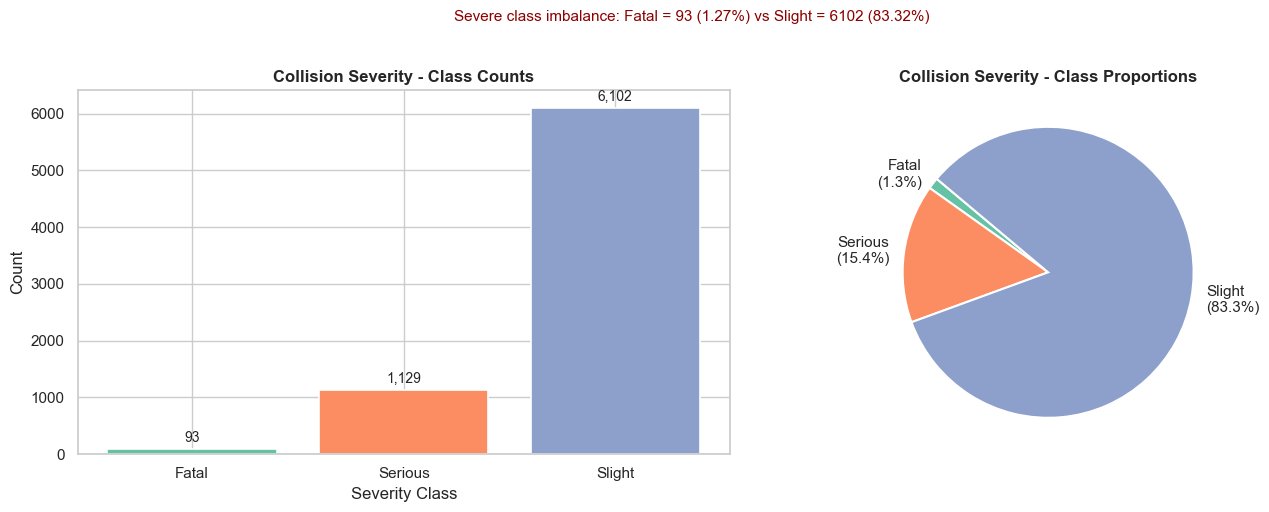

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=tuple(NB_CONFIG['figsize_wide']))

colors = sns.color_palette(NB_CONFIG['palette'], 3)
labels = [NB_CONFIG['severity_labels'][i] for i in class_counts.index]

bars = axes[0].bar(labels, class_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Collision Severity - Class Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severity Class')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, class_counts.values, strict=False):
    axes[0].annotate(
        f'{count:,}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5), textcoords='offset points',
        ha='center', fontsize=10
    )

axes[1].pie(
    class_counts.values,
    labels=[f'{l}\n({p:.1f}%)' for l, p in zip(labels, class_pcts.values, strict=False)],  # noqa: E741
    colors=colors,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Collision Severity - Class Proportions', fontsize=12, fontweight='bold')

fig.suptitle(
    f'Severe class imbalance: Fatal = {class_counts[1]} ({class_pcts[1]}%) vs '
    f'Slight = {class_counts[3]} ({class_pcts[3]}%)',
    fontsize=11, y=1.02, color='darkred'
)
plt.tight_layout()
plt.show()

---
# 5. Stratified Train / Test Split

A stratified split is essential here - it ensures each split contains the same proportion of Fatal, Serious, and Slight cases. Without stratification, the Fatal class (93 records) could be entirely absent from the test set by chance.

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=cfg['supervised']['test_size'],
    random_state=cfg['supervised']['random_state'],
    stratify=y # preserves class proportions in both splits
)

print(f'Training set:  {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X):.0%})')
print(f'Test set:      {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X):.0%})')

Training set:  5,859 rows (80%)
Test set:      1,465 rows (20%)


In [64]:
# Verify stratification held
def class_distribution_df(y_series, split_name):
    counts = y_series.value_counts().sort_index()
    pcts   = (counts / len(y_series) * 100).round(2)
    return pd.DataFrame({
        'Split': split_name,
        'Class': [NB_CONFIG['severity_labels'][i] for i in counts.index],
        'Count': counts.values,
        'Percentage': pcts.values
    })

dist_summary = pd.concat([
    class_distribution_df(y,       'Full dataset'),
    class_distribution_df(y_train, 'Train'),
    class_distribution_df(y_test,  'Test'),
], ignore_index=True)

print('Class distribution across splits:')
print(dist_summary.to_string(index=False))

Class distribution across splits:
       Split   Class  Count  Percentage
Full dataset   Fatal     93        1.27
Full dataset Serious   1129       15.42
Full dataset  Slight   6102       83.32
       Train   Fatal     74        1.26
       Train Serious    903       15.41
       Train  Slight   4882       83.32
        Test   Fatal     19        1.30
        Test Serious    226       15.43
        Test  Slight   1220       83.28


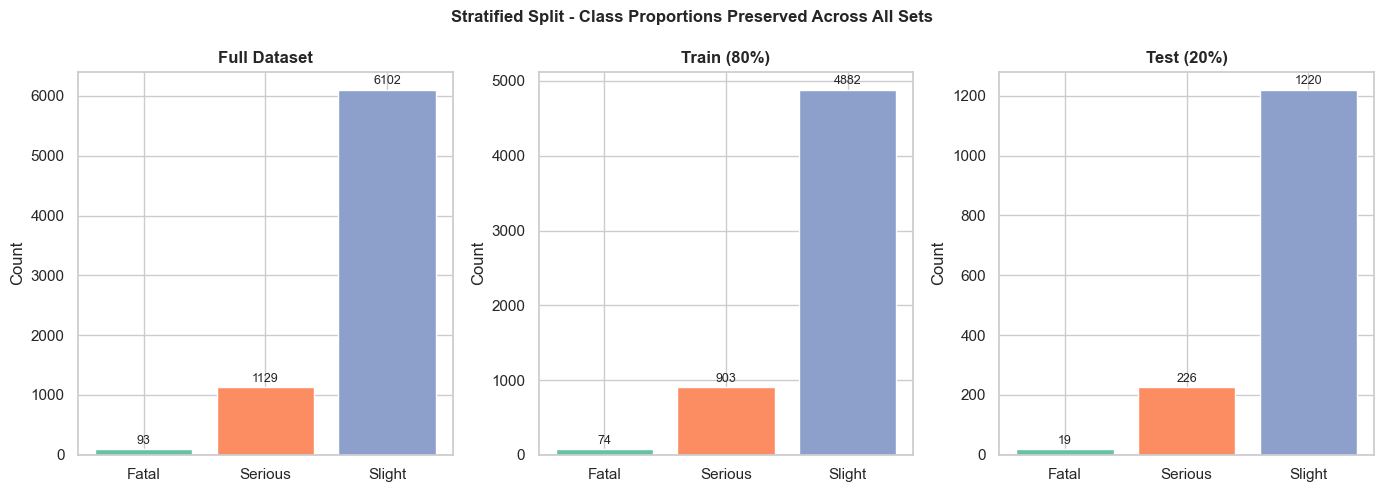

In [65]:
# Visualise split distributions
fig, axes = plt.subplots(1, 3, figsize=tuple(NB_CONFIG['figsize_wide']), sharey=False)

for ax, (split_name, y_split) in zip(axes, [
    ('Full Dataset', y),
    ('Train (80%)', y_train),
    ('Test (20%)', y_test)
], strict=False):
    counts = y_split.value_counts().sort_index()
    labels = [NB_CONFIG['severity_labels'][i] for i in counts.index]
    bars = ax.bar(labels, counts.values, color=colors, edgecolor='white')
    ax.set_title(split_name, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, count in zip(bars, counts.values, strict=False):
        ax.annotate(
            f'{count}',
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4), textcoords='offset points',
            ha='center', fontsize=9
        )

fig.suptitle('Stratified Split - Class Proportions Preserved Across All Sets',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Stage 1 Summary

| Item | Detail |
|------|--------|
| Features | 28 columns after leakage removal |
| Target | `collision_severity` (3 classes) |
| Training samples | 5,859 |
| Test samples | 1,465 |
| Imbalance ratio | ~66:1 (Slight vs Fatal) |
| Split strategy | Stratified 80/20 |

Next: Stage 2 - SMOTE oversampling to address the class imbalance before training

In [66]:
# Persist split data for downstream stages
import os
import pickle

os.makedirs('stage_outputs', exist_ok=True)

with open('stage_outputs/stage1.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test':  X_test,
        'y_train': y_train,
        'y_test':  y_test,
        'pipeline_cfg': cfg,
        'nb_cfg': nb_cfg,
    }, f)

print('Stage 1 outputs saved to stage_outputs/stage1.pkl')

Stage 1 outputs saved to stage_outputs/stage1.pkl
